**Machine learning portofolio 2**

Teamnaam op kaggle: 

Teamleden:
- Chris de Nooijer
- Ids Goonstra
- Haben Sebhatu
- Tom Spoler




**Opdracht 1** - EDA

**1.1 Data inladen**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
df = train.copy()


**1.2 Eerste kijk naar de gegevens**

In [13]:
df

,date_hour,holiday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01 00:00:00,0,1,0.24,0.2879,0.81,0.0000,16
1,2011-01-01 01:00:00,0,1,0.22,0.2727,0.80,0.0000,40
2,2011-01-01 02:00:00,0,1,0.22,0.2727,0.80,0.0000,32
3,2011-01-01 03:00:00,0,1,0.24,0.2879,0.75,0.0000,13
4,2011-01-01 04:00:00,0,1,0.24,0.2879,0.75,0.0000,1
...,...,...,...,...,...,...,...,...
16632,2012-11-30 19:00:00,0,1,0.32,0.3485,0.66,0.0000,377
16633,2012-11-30 20:00:00,0,1,0.32,0.3485,0.66,0.0000,245
16634,2012-11-30 21:00:00,0,1,0.30,0.3182,0.75,0.0896,183
16635,2012-11-30 22:00:00,0,1,0.30,0.3333,0.75,0.0000,163


**1.3 Kolombeschrijving**

|**Naam**|**Meetniveau**|**Toelichting**|
|--------|--------------|---------------|
|date_hour|interval|tijd van waarneming|
|holiday|nominaal|is het een feestdag (0=nee, 1=ja)|
|weathersit|ordinaal|hoe goed het weer is 0=beste, 4=slechtste|
|temp|interval|tempratuur|
|atemp|interval|gevoelstempratuur|
|hum|interval|luchtvochtigheid|
|windspeed|interval|windsnelheid|
|cnt|interval|aantal stukt verhuurd per uur|



**1.4 Kan de data gebruikt worden voor Machine Learning**

*1.4.1 Missende waardes*

In [15]:
train.isna().sum(), test.isna().sum()

(date_hour     0
 holiday       0
 weathersit    0
 temp          0
 atemp         0
 hum           0
 windspeed     0
 cnt           0
 dtype: int64,
 date_hour     0
 holiday       0
 weathersit    0
 temp          0
 atemp         0
 hum           0
 windspeed     0
 dtype: int64)

*1.4.2 Zijn de waardes numeriek*

In [19]:
#df['date_hour'] = pd.to_datetime(df['date_hour'])
df.dtypes

date_hour     datetime64[ns]
holiday                int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
cnt                    int64
dtype: object

Alle waardes zijn numeriek en kunnen dus gebruikt worden voor machine learning, date_hour is een datetime object en met one hot encoding kunnen we omgaan met de holiday en weathersit kolommen

**Correlaties en visualisaties 1.5**

*Extra tijd features maken voor de EDA 1.5.1*

In [20]:
df['year'] = df['date_hour'].dt.year
df['month'] = df['date_hour'].dt.month
df['day'] = df['date_hour'].dt.day
df['hour'] = df['date_hour'].dt.hour
df['weekday'] = df['date_hour'].dt.weekday  # Maandag=0, Zondag=6
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

*Basis tijdseries visualisatie 1.5.2*

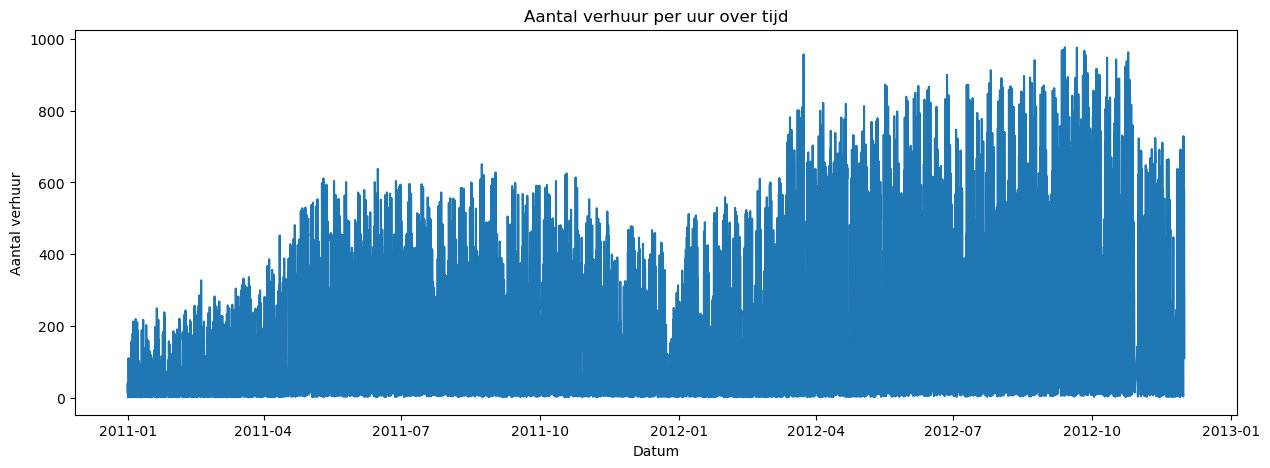

In [21]:
plt.figure(figsize=(15,5))
plt.plot(df['date_hour'], df['cnt'])
plt.title('Aantal verhuur per uur over tijd')
plt.xlabel('Datum')
plt.ylabel('Aantal verhuur')
plt.show()

Uit de grafiek is te zien dat er over de maanden heen geen duidelijke trend is en dat er op maandelijk niveau geen herhalend patroon plaatsvindt

*Seizoenspatronen visualiseren 1.5.3*

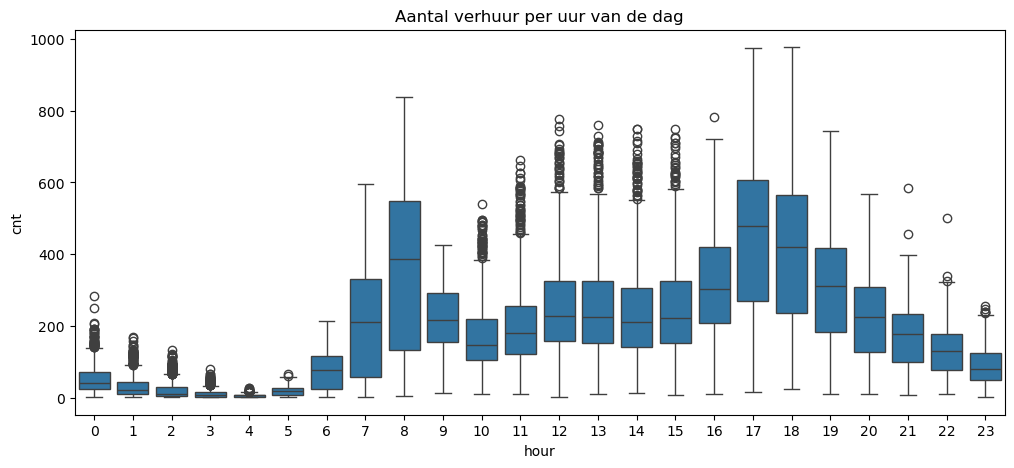

In [26]:
plt.figure(figsize=(12,5))
sns.boxplot(x='hour', y='cnt', data=df)
plt.title('Aantal verhuur per uur van de dag')
plt.show()

De meeste stuks worden in het begin van de ochtend of einde van de middag verhuurd

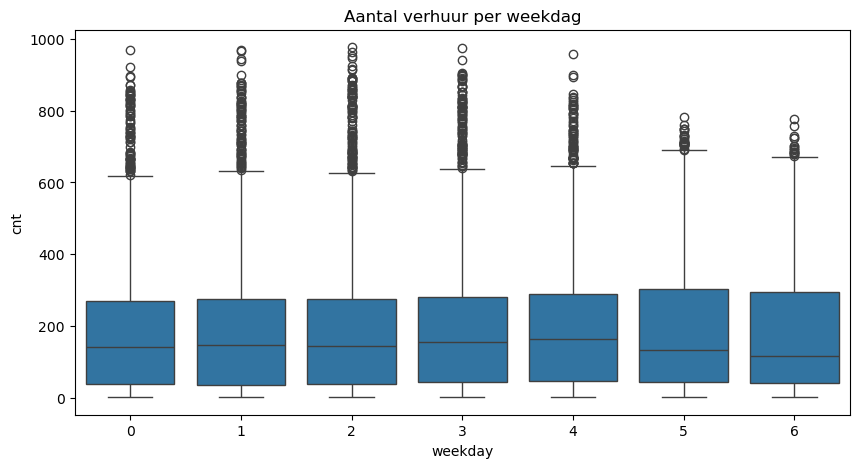

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(x='weekday', y='cnt', data=df)
plt.title('Aantal verhuur per weekdag')
plt.show()

De meeste stuks worden verhuurd buiten het weekend om, daar zijn duidelijk minder outliers mediaan ligt ook lager.

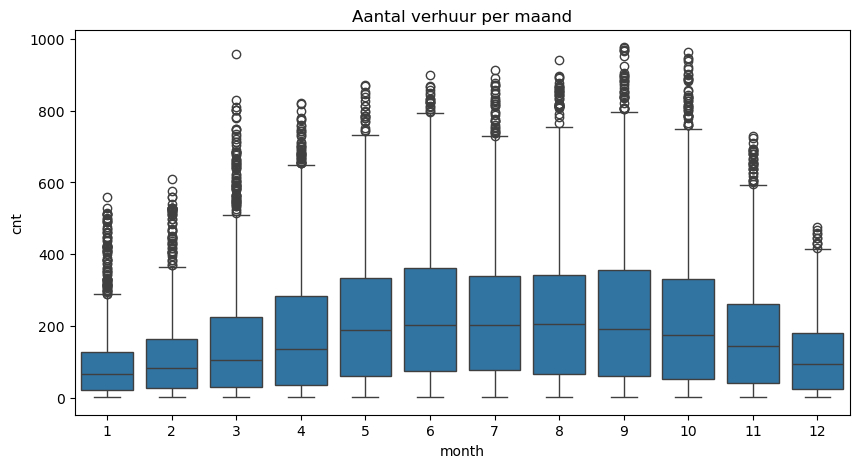

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(x='month', y='cnt', data=df)
plt.title('Aantal verhuur per maand')
plt.show()

Tussen mei en oktober worden gemiddeld de meeste stuks verhuurd met veruit het het laagste aantal verhuur per maand in januari.

*De relaties met andere features 1.5.4*

<Figure size 1000x1000 with 0 Axes>

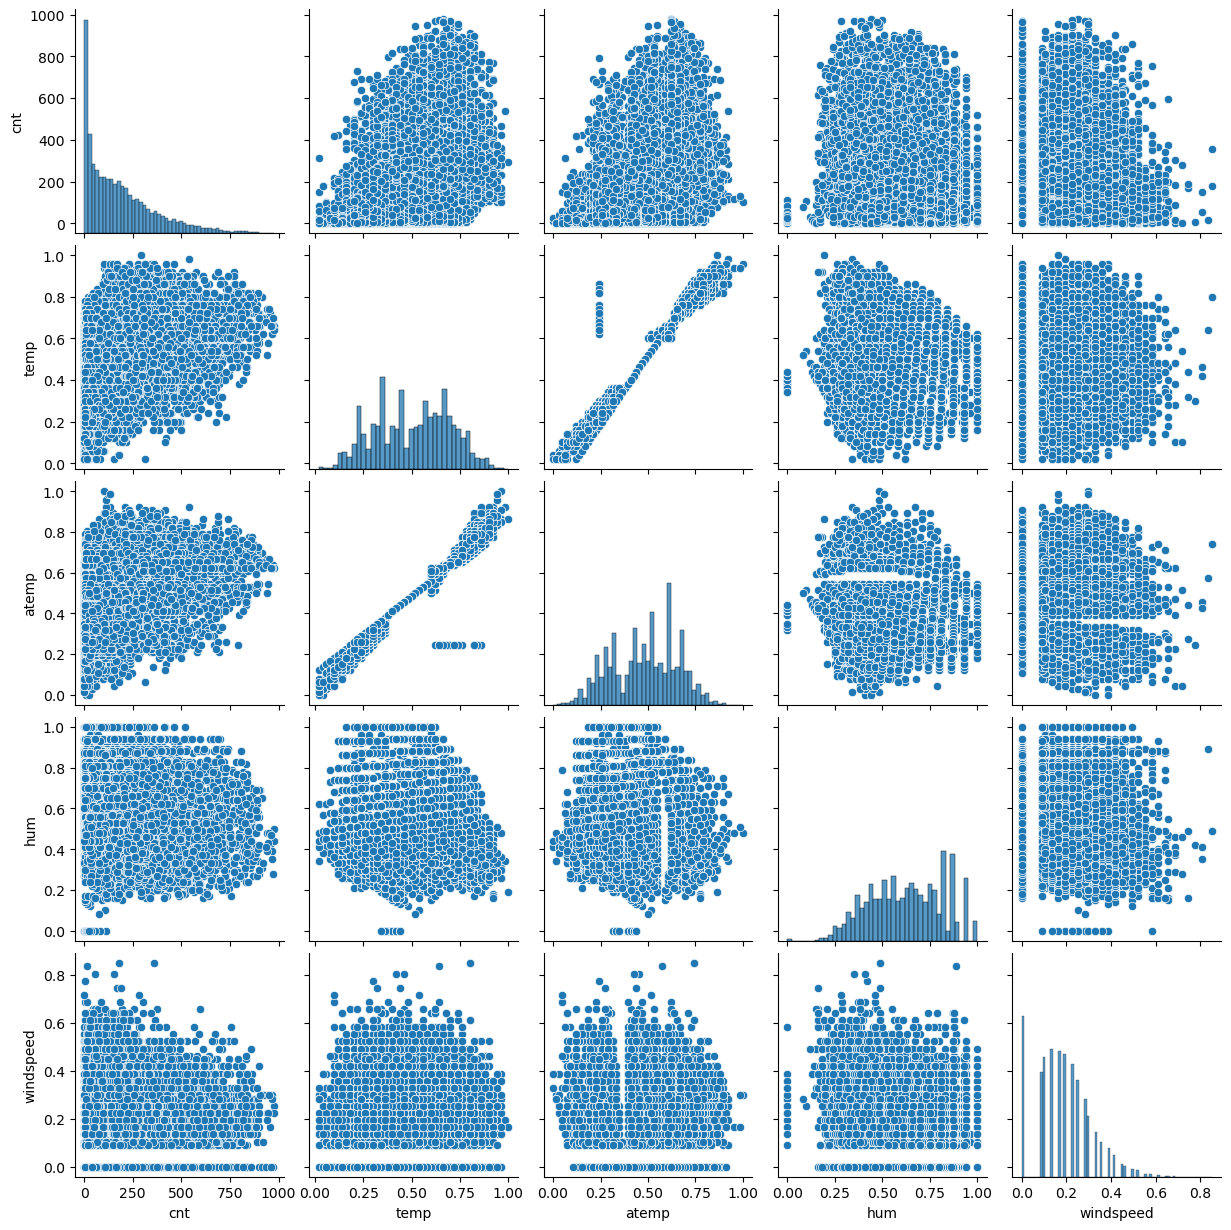

In [32]:
#numerieke variabelen
plt.figure(figsize=(10,10))
sns.pairplot(df[['cnt','temp','atemp','hum','windspeed']])
plt.show()

Door de pairplot kunnen we een paar conclusies trekken:
Hogere windsnelheden zorgen voor minder verhuurde stuks, en een hogere vochtigheid en (gevoels)tempratuur zorgen juist voor meer verhuurde stuks

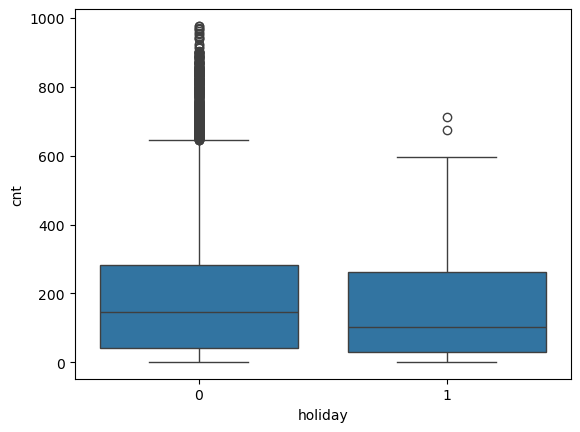

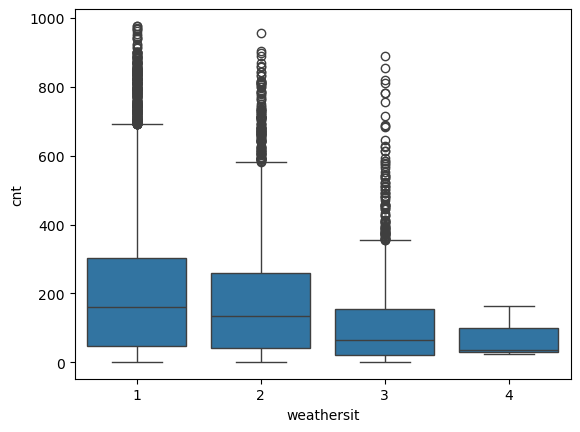

In [33]:
#categoriale variabelen
sns.boxplot(x='holiday', y='cnt', data=df)
plt.show()

sns.boxplot(x='weathersit', y='cnt', data=df)
plt.show()


Tijdens feestdagen worden minder stuks verhuurd, er zijn opmerkelijk veel minder outliers en de mediaan ligt ook lager. Naarmate de weersomstandigheden verslechteren daalt het aantal verhuurde stuks ook drastisch.

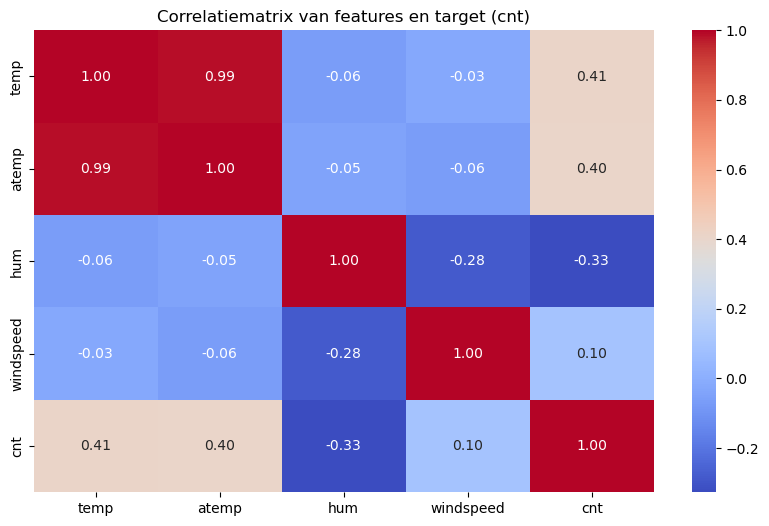

In [36]:
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
df_numeric = df[numeric_cols]
corr_matrix = df_numeric.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlatiematrix van features en target (cnt)')
plt.show()

Het aantal verhuurde stuks correleerd het meeste met de tempratuur en ook redelijk met de vochtigheid. De warmer het is de meer stuks worden verhuurd. Naarmate het vochtiger wordt worden er juist minder stuks verkocht. Ook is er sterke multicollineariteit tussen de temp en atemp kolom en dat is erg logisch omdat de een daadwerkelijke tempratuur is en de ander de gevoelstempratuur. Hierdoor is het slim om de kolom atemp te verwijderen.

In [ ]:
df.drop(columns=['atemp'], inplace=True)

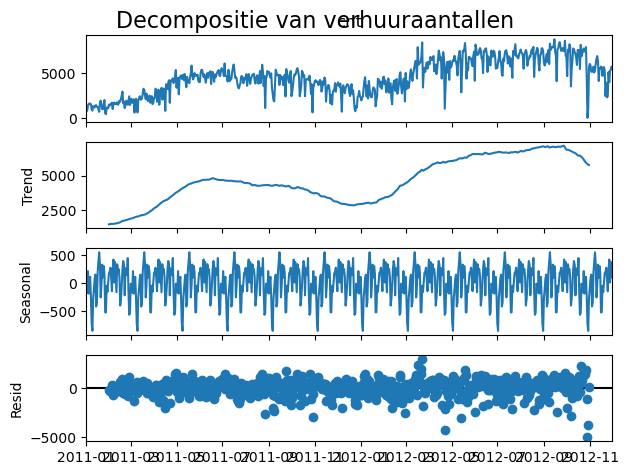

In [93]:
df_ts = df.set_index('date_hour')['cnt']
df_daily = df_ts.resample('d').sum()

result = seasonal_decompose(df_daily, period=60, model='additive')
result.plot()
plt.suptitle('Decompositie van verhuuraantallen', fontsize=16)
plt.show()

Door middel van de seasonal decompose op dagelijks niveau met een period van 60 is het erg duidelijk dat er een seizoenspatroon is, met een cyclus die 60 dagen duurt.

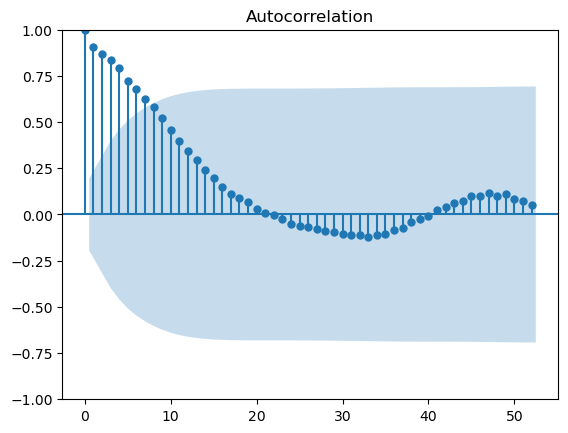

In [95]:
from statsmodels.graphics.tsaplots import plot_acf

df_weekly = df_ts.resample('W').sum()
plot_acf(df_weekly, lags=52)  # 30 dagen
plt.show()

De autocorrelatie van de wekelijkse verhuuraantallen laat zien dat de dagelijkse waarden slechts zwak gecorreleerd zijn met voorgaande dagen. Er is een lichte negatieve trend zichtbaar tussen lag 20 en 40, en kleine terugkerende patronen na lag 40. Dit wijst op een langzaam afnemende trend met zwakke herhalingen, wat aantoont dat de verhuuraantallen voornamelijk ruisachtig zijn met kleine cyclische patronen.